In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import pathlib

In [26]:
!python --version

Python 3.13.15


In [27]:
print(tf.__version__)

2.20.0


In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'autompg-dataset' dataset.
Path to dataset files: /kaggle/input/autompg-dataset


In [29]:
# Importar el dataset en un DataFrame desde la ruta de KaggleHub
dataset_file = pathlib.Path(path) / "auto-mpg.csv"

if not dataset_file.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {dataset_file}")

df = pd.read_csv(dataset_file)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [30]:
#validar celdas nulas de df
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [31]:
# Preparar las columnas numéricas y separar la característica objetivo
# '?' en horsepower representa un valor faltante.
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

X = df.drop(columns=['mpg'])
y = df['mpg']

# Dividir 80% de train en X e y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
#Dividir 80% de train en X, y colocar la característica mpg
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

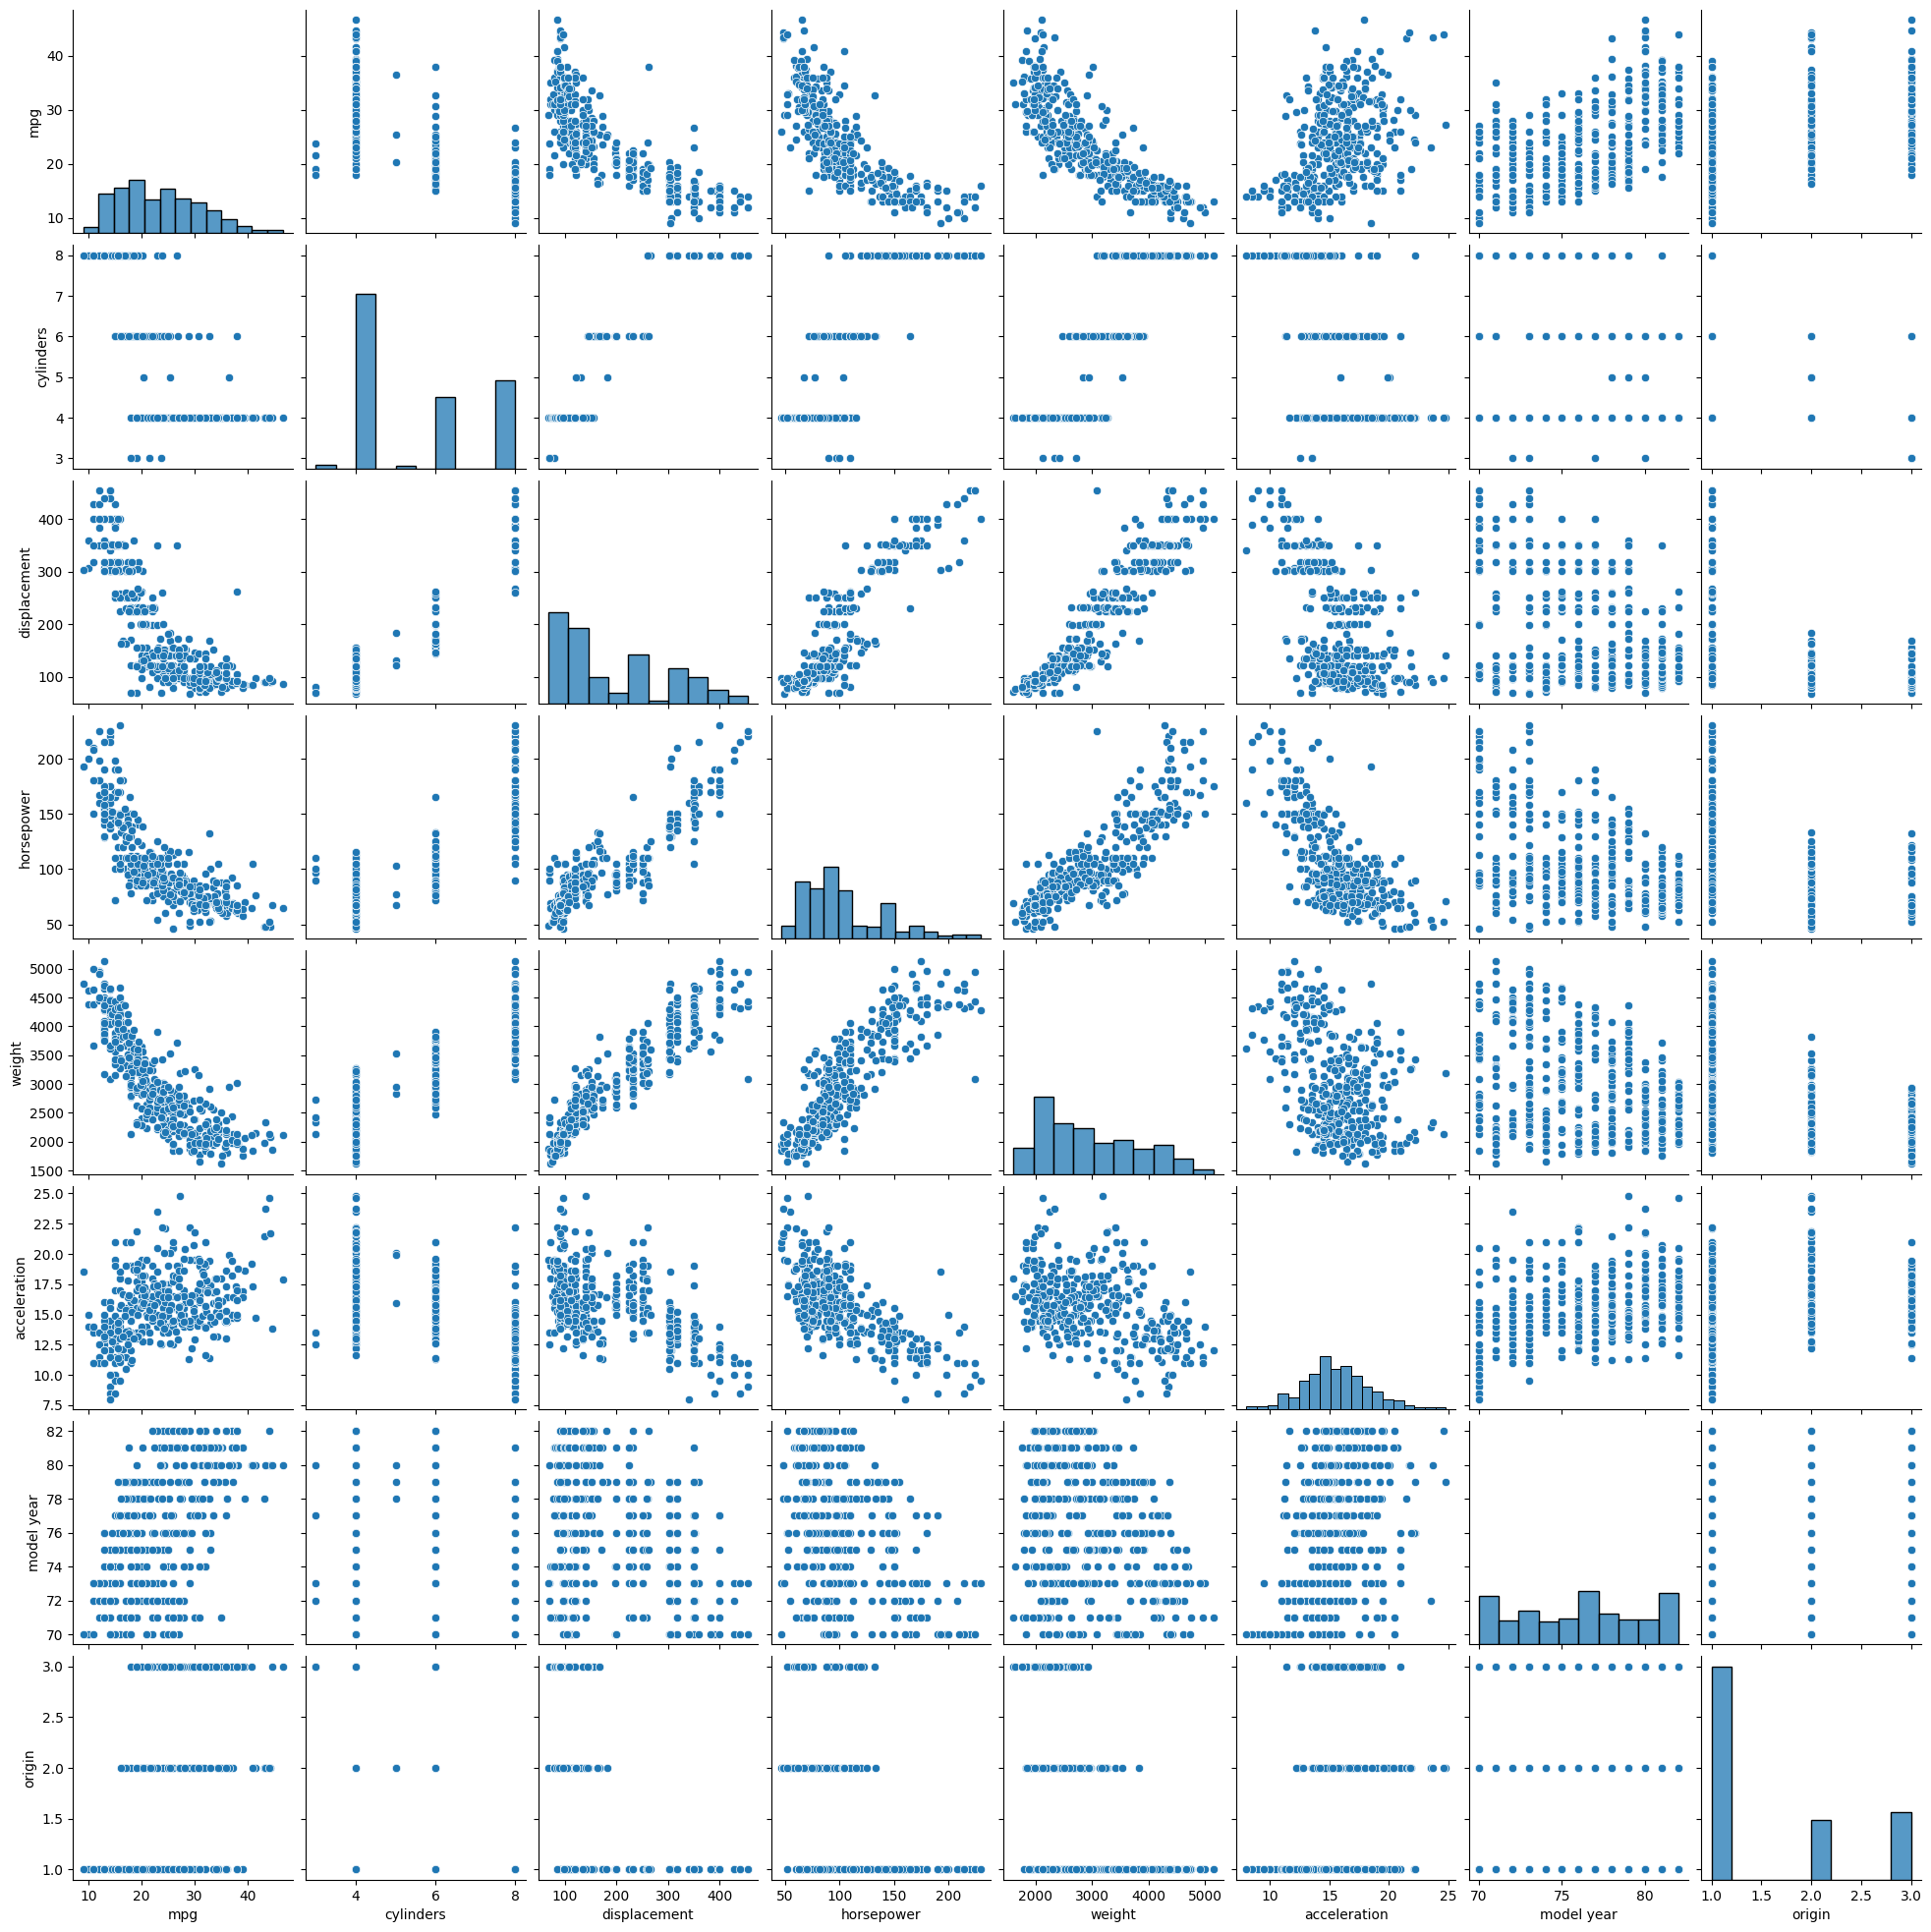

In [33]:
# Analizar las relaciones entre las variables del DataFrame con Seaborn
sns.pairplot(df, diag_kind="hist")
plt.show()

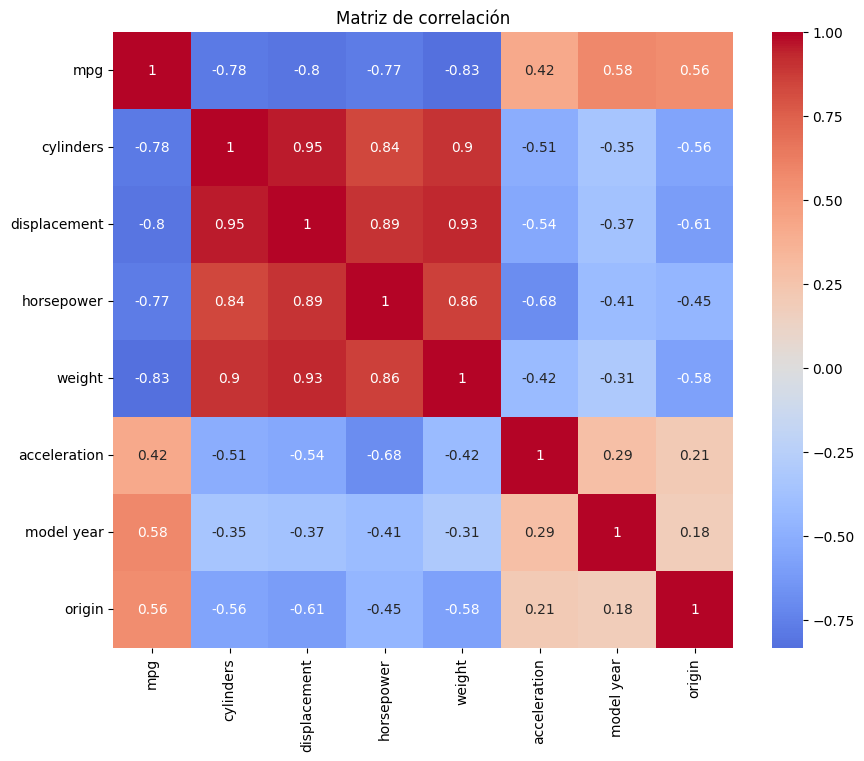

In [34]:
# Mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.show()

In [35]:
# convertir horsepower en float,  reemplazando '?' por la media
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [36]:
#imputar en horsepower en el nan la media de horsepower
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

In [37]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [38]:
# Dividir el dataset en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Normalizar

In [39]:
# Normalizar los datos de entrenamiento y prueba
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'amc rebel sst'

In [ ]:
X_train_scaled

In [ ]:
# Crear el modelo secuencial
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='linear')
])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.005), loss='mse', metrics=['mae']) 


In [ ]:
# Entrenar y evaluar el modelo
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Error cuadrático medio en prueba: {test_loss:.3f}')
print(f'Error absoluto medio en prueba: {test_mae:.3f}')
model.summary()

Error cuadrático medio en prueba: 5.451
Error absoluto medio en prueba: 1.824


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,860 (7.27 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 931 (3.64 KB)

In [40]:
history = model.fit(
    X_train_scaled,y_train,epochs=500, batch_size=32, validation_split=0.2) 

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 8.2737 - mae: 2.0001 - val_loss: 7.3776 - val_mae: 2.0032
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.4714 - mae: 1.9503 - val_loss: 7.4660 - val_mae: 1.9571
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.8323 - mae: 1.9651 - val_loss: 7.9221 - val_mae: 2.1768
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.9026 - mae: 1.8300 - val_loss: 9.6263 - val_mae: 2.5454
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.2328 - mae: 1.9632 - val_loss: 8.2896 - val_mae: 2.2504
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.5201 - mae: 1.8139 - val_loss: 8.9139 - val_mae: 2.3436
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.8000 - mae: 1.8608 - val_loss: 8.0263 - val_mae: 2.1131
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5702 - mae: 1.9301 - val_loss: 7.3299 - val_mae: 2.0949
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 6.6354 - mae: 

Text(0, 0.5, 'Pérdida')

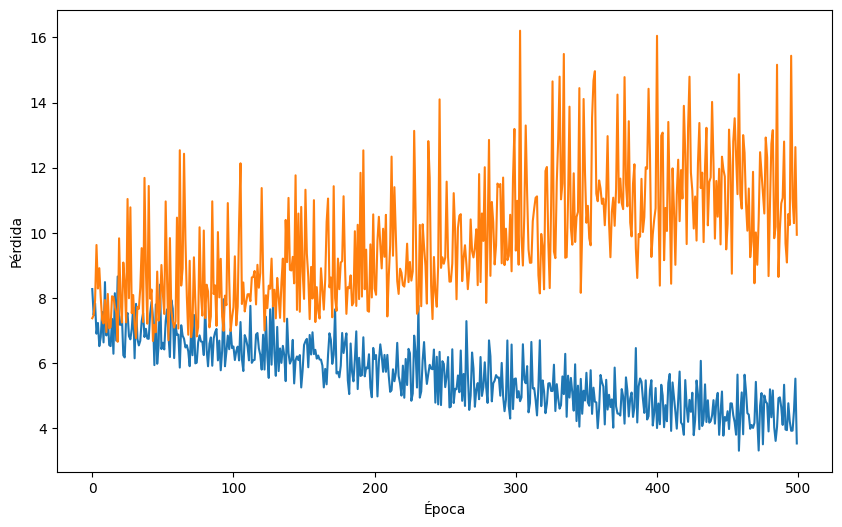

In [42]:
#Graficame el history de los datos de entrenamiento y datos de valuación, las metricas y la función de perdida
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')